# Preparation

## 1. Importing libraries and files

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import json

pd.options.display.float_format = '{:.2f}'.format
print("OK")

OK


In [7]:
main_dir = "../.."
raw_data = pd.read_csv(f"{main_dir}/data/raw/raw_dataset.csv")
dataset = pd.read_csv(f"{main_dir}/data/clean_dataset.csv")
cords = pd.read_csv(f"{main_dir}/data/external/cords.csv", dtype={"xcords":str, "ycords":str})
with open(f"{main_dir}/data/external/be.json") as f:
    be = json.load(f)
    f.close()
colors = {"color1": "#127FC3",
          "color3": "#C6104D",
          "color4": "#47C550",
          "color2": "#F2D544",
          "facecolor": "#F7F7F7",
          "facecolor2": "#D7D7D7"
}
print("OK")

FileNotFoundError: [Errno 2] No such file or directory: '../../data/external/cords.csv'

Checking raw dataset

In [12]:
raw_data.isna().sum()

Locality                     0
Type of property             0
Subtype of property          0
Price                      513
Number of rooms            541
Living Area               1773
Terrace Area             16413
Garden Area              21076
Surface of the land      13331
Number of facades         6305
State of the building     6113
Furnished                    0
Terrace                      0
Garden                       0
Swimming pool                0
dtype: int64

There is a lot data to clean.
- We may remove terace area and garder area because these fields almost empty. Also we have boolean value about these parameters.
- State of building was changed to numbers.
- Priceless rows removed
- Surface of the land was filled with 0 when NA for appartments
- Locality cleaned and changed to Region + Municipality
- Created indexing of rows. We prevent duplicates in data, so all properties are unique even if looks same
- All collumns renamed for friendly coding.

In [13]:
dataset.head()

,index,type,subtype,price,living_area,land_area,facades,state,furnished,terrace,garden,pool,region,municipality
0,0,house,residence,90000,120,235,2,2,False,True,True,False,Walloon Region,Chièvres
1,1,apartment,apartment,90000,49,0,2,6,False,True,False,False,Walloon Region,Charleroi
2,2,house,residence,90000,165,1410,4,2,False,False,True,False,Walloon Region,Frasnes-lez-Anvaing
3,3,house,residence,90000,115,269,2,2,False,True,False,False,Walloon Region,Dour
4,4,house,residence,90000,113,170,2,2,False,True,True,False,Walloon Region,Dour


## Removing number of rooms

In [15]:
rooms = dataset.iloc[100:-100,3:6]
rooms.price = rooms.price.apply(lambda x: round(x / 100000) * 100000)
rooms = rooms.groupby("price").mean().reset_index()
print("Correlation between Living area and Number of rooms is: ",
      rooms.corr().iloc[1,2] * 100 // 1 / 100, sep = "")

Correlation between Living area and Number of rooms is: 0.95


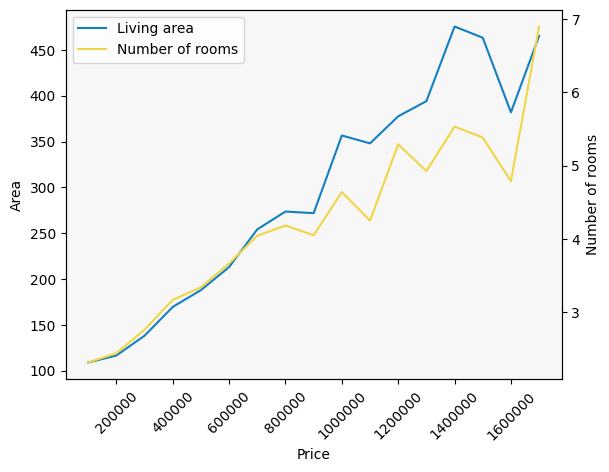

In [16]:
fig, ax = plt.subplots()
l1, = ax.plot(rooms.price, rooms.living_area, color = colors["color1"], label = "Living area")
ax2 = ax.twinx()
l2, = ax2.plot(rooms.price, rooms["Number of rooms"], color = colors["color2"], label = "Number of rooms")
ax.legend(handles = [l1, l2])
ax.set_xlabel("Price")
ax.ticklabel_format(style="plain", axis = "x")
ax.tick_params(axis="x", rotation=45)
ax.set_ylabel("Area")
ax2.set_ylabel("Number of rooms")
ax.set_facecolor(color = colors["facecolor"])
plt.show()
fig.savefig("plots/number_of_rooms.png", bbox_inches="tight")

For this reason Number of rooms was removed from data. Because as price depended on Living area - it is same way depended on Number of rooms.

# Analysis

## Living area to Price ratio

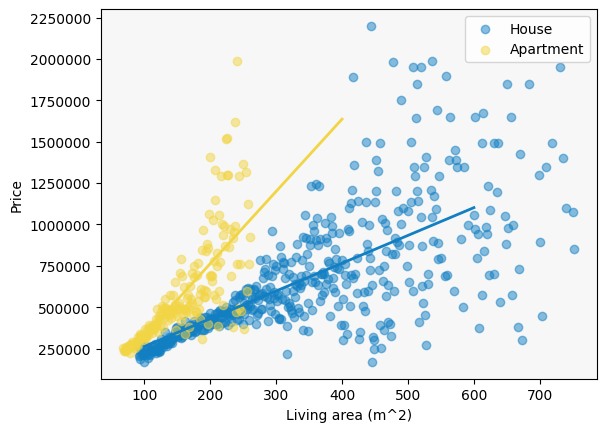

In [31]:
house_living_area = dataset[dataset.type == "house"].groupby("living_area")["price"].mean().to_frame().reset_index().iloc[50:-50]
apartment_living_area = dataset[dataset.type == "apartment"].groupby("living_area")["price"].mean().to_frame().reset_index().iloc[50:-50]
fig, ax = plt.subplots()
ax.scatter(house_living_area.living_area, house_living_area.price, color=colors["color1"], alpha = .5)
ax.scatter(apartment_living_area.living_area, apartment_living_area.price, color=colors["color2"], alpha = .5)
line_house = np.poly1d(np.polyfit(house_living_area.living_area, house_living_area.price, 1))
line_apartment = np.poly1d(np.polyfit(apartment_living_area.living_area, apartment_living_area.price, 1))
line_xrange_house = np.linspace(100, 600)
line_xrange_apartment = np.linspace(100, 400)
ax.plot(line_xrange_house, line_house(line_xrange_house), color=colors["color1"], lw=2)
ax.plot(line_xrange_apartment, line_apartment(line_xrange_apartment), color=colors["color2"], lw=2)

ax.legend(["House", "Apartment"])
ax.set_xlabel("Living area (m^2)")
ax.set_ylabel("Price")
ax.ticklabel_format(style='plain', axis='y')
ax.set_facecolor(colors["facecolor"])
plt.show()
fig.savefig("plots/living_area_to_price.png", bbox_inches="tight")

In [46]:
dataset[dataset.type == "apartment"].sort_values("living_area", ascending = False).iloc[10:,1:5].head(10)

,type,subtype,price,living_area
13734,apartment,apartment,895000,444
12486,apartment,apartment,595000,430
14012,apartment,apartment,1100000,429
12644,apartment,apartment,610000,403
14210,apartment,duplex,1390000,399
11015,apartment,apartment,480000,380
13946,apartment,apartment,998800,376
13947,apartment,penthouse,999000,370
14023,apartment,apartment,1125000,368
13469,apartment,loft,795000,365


In [42]:
print("Correlation between Living area and Price for houses is: ",
      house_living_area.corr().iloc[0, 1] * 100 // 1 / 100, sep = "")
print("Correlation between Living area and Price for apartments is: ",
      apartment_living_area.corr().iloc[0, 1] * 100 // 1 / 100, sep = "")

Correlation between Living area and Price for houses is: 0.7
Correlation between Living area and Price for apartments is: 0.74


## Price based on Subtype

Checking if **STD** is lower than **MEAN**.

In [58]:
temp = dataset.groupby("subtype")["price"].agg(["std", "mean"])
temp.iloc[:,:]
temp

,std,mean
subtype,,
apartment,213127,339361
bungalow,118409,342455
chalet,109048,232887
cottage,319356,547416
duplex,227637,380774
ground-floor,190489,333665
loft,292508,494618
mansion,436643,1237500
master-house,433594,688747


Results: **STD** gives lower values than **MEAN**. So we can use **MEAN** to create Bar Chart for Subtypes and Prices.

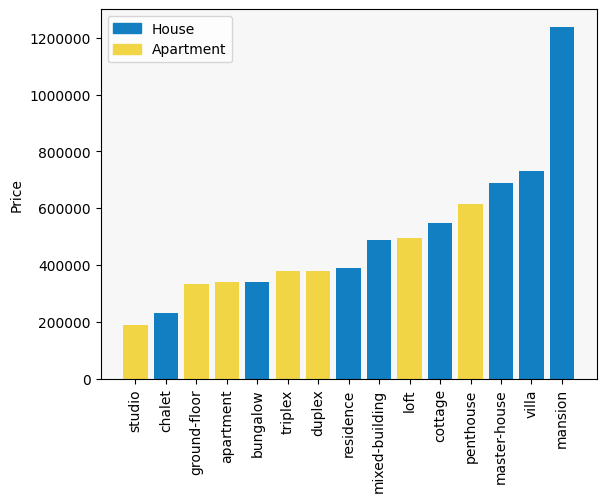

In [23]:
subtypes = dataset.groupby(["type", "subtype"])["price"].mean().to_frame().reset_index().sort_values("price")
subtypes["color"] = subtypes["type"].apply(lambda x: colors["color1"] if x == "house" else colors["color2"])
legend = [
    Patch(color=colors["color1"], label = "House"),
    Patch(color=colors["color2"], label = "Apartment")
]
fig, ax = plt.subplots()
ax.bar(subtypes.subtype, subtypes.price, color=subtypes.color)
ax.legend(handles = legend)
ax.set_ylabel("Price")
ax.ticklabel_format(style="plain", axis="y")
ax.set_facecolor(colors["facecolor"])
plt.xticks(rotation=90)
plt.show()
fig.savefig("plots/house_type.png", bbox_inches="tight")

## Locality

In [252]:
loc = dataset[["type", "price", "region", "municipality"]]
loc_w = loc[loc.region == "Walloon Region"].groupby("municipality")["price"].mean().to_frame().reset_index().sort_values("price")
loc_f = loc[loc.region == "Flemish Region"].groupby("municipality")["price"].mean().to_frame().reset_index().sort_values("price")
loc_b = loc[loc.region == "Brussels-Capital Region"].groupby("municipality")["price"].mean().to_frame().reset_index().sort_values("price")
mun = {}
for i, line in cords.iterrows():
    mun[line["municipality"]] = [line["xcords"], line["ycords"]]

In [257]:
high_w = loc_w.tail(10)["municipality"].to_list()
low_w = loc_w.head(10)["municipality"].to_list()
high_f = loc_f.tail(10)["municipality"].to_list()
low_f = loc_f.head(10)["municipality"].to_list()
high_b = loc_b.tail(5)["municipality"].to_list()
low_b = loc_b.head(5)["municipality"].to_list()

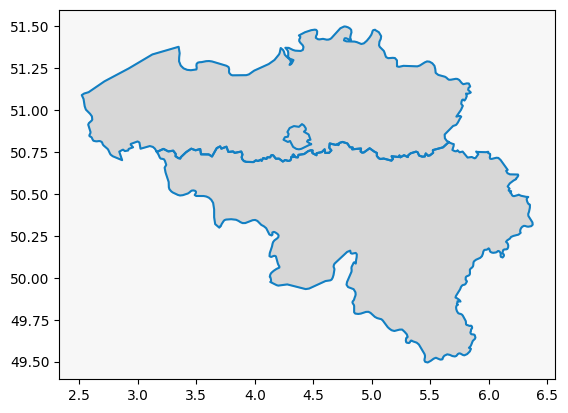

In [274]:
def outer_ring_of_largest(geom):
    coords = geom["coordinates"]
    if geom["type"] == "Polygon":
        return coords[0]
    else:
        largest_poly = max(coords, key=lambda poly: len(poly[0]))
        return largest_poly[0]

fig, ax = plt.subplots()

ring = outer_ring_of_largest(be["features"][1]["geometry"])
xs = [p[0] for p in ring]
ys = [p[1] for p in ring]
ax.fill(xs, ys, color=colors["facecolor2"])
ax.plot(xs, ys, color=colors["color1"])
ring = outer_ring_of_largest(be["features"][2]["geometry"])
xs = [p[0] for p in ring]
ys = [p[1] for p in ring]
ax.fill(xs, ys, color=colors["facecolor2"])
ax.plot(xs, ys, color=colors["color1"])
ring = outer_ring_of_largest(be["features"][0]["geometry"])
xs = [p[0] for p in ring]
ys = [p[1] for p in ring]
ax.plot(xs, ys, color=colors["color1"])
ax.set_facecolor(color = colors["facecolor"])
plt.show()